# 🧩 Process Mining with PM4Py
Este notebook demonstra um fluxo completo de *Process Mining* usando a biblioteca **PM4Py**:
- Importação e preparação do log de eventos (.XES)
- Exploração do log
- Aplicação de diferentes mineradores (Heuristics Miner, Inductive Miner)
- Avaliação e conformidade do modelo

> Author: Afonso Sarmento Rodrigues

> University: TU/e (Eindhoven University of Technology)


In [ ]:
import os
import pandas as pd
import pm4py  # version 2.7.4
from pprint import pprint  # pretty printing
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation import algorithm as evaluation
from pm4py.objects.conversion.log import converter as stream_converter
from pm4py.objects.log.importer.xes import importer as xes_import
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualizer
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display

## 📂 Importar o log de eventos
Carregamos um log `.xes` (gerado, por exemplo, pelo ProM), e o convertemos em um DataFrame do Pandas para fácil manipulação.


In [2]:
# Caminho do arquivo XES (deve estar no mesmo diretório)
file_path = os.path.join(os.getcwd(), "event_log_prom_clean.xes")

# 1. Ler o log de eventos
log = xes_import.apply(file_path)
log_df = pm4py.convert.convert_to_dataframe(log)

log_df.head()

c:\Users\afons\AppData\Local\Programs\Python\Python310\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/110 [00:00<?, ?it/s]

,bg_ts,value,time:timestamp,concept:name,source_file,bolus_ts,bolus_dose,meal_ts,meal_type,meal_tag,...,met,intensity,motion_intensity_mean,motion_intensity_max,basal_ts,basal_dose,insulin_kind,Unnamed: 3,Unnamed: 4,case:concept:name
0,2023-01-10 00:04:00+00:00,7.5,2023-10-01 00:04:00+00:00,glucose,glucose,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,2023-10-01 00:00:00+00:00
1,2023-01-10 00:09:00+00:00,8.0,2023-10-01 00:09:00+00:00,glucose,glucose,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,2023-10-01 00:00:00+00:00
2,2023-01-10 00:14:00+00:00,8.6,2023-10-01 00:14:00+00:00,glucose,glucose,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,2023-10-01 00:00:00+00:00
3,2023-01-10 00:19:00+00:00,9.2,2023-10-01 00:19:00+00:00,glucose,glucose,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,2023-10-01 00:00:00+00:00
4,2023-01-10 00:24:00+00:00,9.7,2023-10-01 00:24:00+00:00,glucose,glucose,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,2023-10-01 00:00:00+00:00


## ⏱️ Preparação dos dados e definição da *case notion*
Vamos garantir que o timestamp esteja no formato correto e definir o que será considerado um *case*.
Neste exemplo, definimos **um caso por dia**.


In [3]:
log_df['time:timestamp'] = pd.to_datetime(log_df['time:timestamp'])
log_df['case_id'] = log_df['time:timestamp'].dt.date.astype(str)

# Reformatar o log para o padrão PM4Py
log_df = pm4py.format_dataframe(
    log_df,
    case_id='case_id',
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

# Converter de volta para EventLog
log = pm4py.convert_to_event_log(log_df)


## 🔎 Exploração inicial do log
Aqui inspecionamos a estrutura dos traces e eventos, número de instâncias e atividades iniciais/finais.


In [4]:
# Estrutura de um trace
print("TRACE KEYS:", list(log[0].attributes.keys()))
print("EVENT KEYS:", list(log[0][0].keys()))

print("Número de traces:", len(log))

event_stream = stream_converter.apply(log, variant=stream_converter.Variants.TO_EVENT_STREAM)
print("Número de eventos:", len(event_stream))

# Atividades únicas
print("\nAtividades únicas:", log_df['concept:name'].unique())

# Atividades iniciais e finais
print("\nAtividades iniciais:", pm4py.get_start_activities(log))
print("Atividades finais:", pm4py.get_end_activities(log))


TRACE KEYS: ['concept:name']
EVENT KEYS: ['bg_ts', 'value', 'time:timestamp', 'concept:name', 'source_file', 'bolus_ts', 'bolus_dose', 'meal_ts', 'meal_type', 'meal_tag', 'carbs_g', 'prot_g', 'fat_g', 'fibre_g', 'calendar_date', 'duration_in_sec', 'start_date_ts', 'start_time_offset_s', 'unmeasurable_sleep_s', 'deep_sleep_s', 'light_sleep_s', 'rem_sleep_s', 'awake_s', 'sleep_levels_map.deep', 'sleep_levels_map_light', 'sleep_levels_map_awake', 'sleep_levels_map_rem', 'Unnamed: 13', 'sleep_levels_map_unmeasurable', 'validation', 'activity_ts', 'activity_type', 'active_Kcal', 'step_count', 'distance_m', 'duration_s', 'active_time_s', 'start_time_s', 'met', 'intensity', 'motion_intensity_mean', 'motion_intensity_max', 'basal_ts', 'basal_dose', 'insulin_kind', 'Unnamed: 3', 'Unnamed: 4', 'case_id', '@@index', '@@case_index']
Número de traces: 110
Número de eventos: 67943

Atividades únicas: <StringArray>
['glucose', 'activity', 'meal', 'basal', 'bolus']
Length: 5, dtype: string

Atividades

In [5]:
log_df[['case:concept:name', 'concept:name', 'time:timestamp']].head(10)


,case:concept:name,concept:name,time:timestamp
0,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:04:00+00:00
1,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:09:00+00:00
2,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:14:00+00:00
3,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:19:00+00:00
4,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:24:00+00:00
5,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:29:00+00:00
6,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:34:00+00:00
7,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:39:00+00:00
8,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:44:00+00:00
9,2023-10-01 00:00:00+00:00,glucose,2023-10-01 00:49:00+00:00


## 🔚 Filtrar casos que terminam com a atividade *End*
Isso ajuda a analisar apenas execuções completas do processo.


In [6]:
# --- safer filtering + diagnostics ---
end_acts = list(pm4py.get_end_activities(log).keys())
print("End activities encontradas:", end_acts)

# se não houver end_acts, mantém o log original (evita filtered_log vazio)
if end_acts:
    filtered_log = pm4py.filter_end_activities(log, end_acts)
else:
    filtered_log = log

print("Número de traces (log):", len(log))
print("Número de traces (filtered):", len(filtered_log))

# utilitário para sumarizar Petri nets
def print_petri_summary(net, im, fm, name="net"):
    if net is None:
        print(f"{name}: None")
        return
    print(f"{name} - places:", len(net.places), "transitions:", len(net.transitions), "arcs:", len(net.arcs))
    labels = [t.label for t in net.transitions if getattr(t, "label", None)]
    print(f"{name} - transition labels (excl. tau):", labels)



End activities encontradas: ['glucose', 'basal']
Número de traces (log): 110
Número de traces (filtered): 110


## ⚙️ Descoberta de processos
Aplicamos os principais algoritmos de descoberta de modelos de processo:
- **Heuristics Miner**
- **Inductive Miner**



In [7]:
# --- discovery (protegido contra logs vazios) ---
# Heuristics Miner (gera PetriNet diretamente)
h_net, h_im, h_fm = heuristics_miner.apply(log)
hf_net, hf_im, hf_fm = heuristics_miner.apply(filtered_log) if len(filtered_log) > 0 else (None, None, None)

print_petri_summary(h_net, h_im, h_fm, "Heuristics (full)")
print_petri_summary(hf_net, hf_im, hf_fm, "Heuristics (filtered)")

# Inductive Miner -> ProcessTree -> Petri
i_tree = inductive_miner.apply(log)
i_net, i_im, i_fm = pt_converter.apply(i_tree)
print("i_tree repr:", repr(i_tree))
print_petri_summary(i_net, i_im, i_fm, "Inductive -> Petri (full)")

if len(filtered_log) > 0:
    if_tree = inductive_miner.apply(filtered_log)
    if_net, if_im, if_fm = pt_converter.apply(if_tree)
    print("if_tree repr:", repr(if_tree))
    print_petri_summary(if_net, if_im, if_fm, "Inductive -> Petri (filtered)")
else:
    if_tree = None
    if_net = None
    if_im = None
    if_fm = None
    print("filtered_log vazio -> Inductive (filtered) não aplicado")



Heuristics (full) - places: 12 transitions: 28 arcs: 58
Heuristics (full) - transition labels (excl. tau): ['activity', 'bolus', 'basal', 'meal', 'glucose']
Heuristics (filtered) - places: 12 transitions: 28 arcs: 58
Heuristics (filtered) - transition labels (excl. tau): ['glucose', 'basal', 'bolus', 'activity', 'meal']
i_tree repr: +( *( ->( X( tau, *( 'meal', tau ) ), 'glucose' ), tau ), X( tau, +( X( tau, *( 'activity', tau ) ), X( tau, *( ->( 'basal', X( tau, *( 'bolus', tau ) ) ), tau ) ) ) ) )
Inductive -> Petri (full) - places: 20 transitions: 27 arcs: 58
Inductive -> Petri (full) - transition labels (excl. tau): ['meal', 'bolus', 'glucose', 'basal', 'activity']
if_tree repr: +( *( ->( X( tau, *( 'meal', tau ) ), 'glucose' ), tau ), X( tau, +( X( tau, *( 'activity', tau ) ), X( tau, *( ->( 'basal', X( tau, *( 'bolus', tau ) ) ), tau ) ) ) ) )
Inductive -> Petri (filtered) - places: 20 transitions: 27 arcs: 58
Inductive -> Petri (filtered) - transition labels (excl. tau): ['bolus

## ⚙️ Criação de Directly-Follows Graph



Usando log: filtered_log
Número de traces no log escolhido: 110
Top directly-follows (orig -> dest : count):
  glucose -> glucose : 30383
  basal -> glucose : 10197
  glucose -> basal : 8462
  glucose -> activity : 6321
  activity -> glucose : 4747
  activity -> activity : 3113
  activity -> basal : 2289
  basal -> activity : 605
  glucose -> bolus : 413
  bolus -> glucose : 216
  bolus -> meal : 200
  meal -> glucose : 190
  bolus -> basal : 137
  basal -> bolus : 115
  glucose -> meal : 92
  bolus -> bolus : 81
  basal -> basal : 61
  activity -> bolus : 53
  meal -> activity : 52
  bolus -> activity : 43


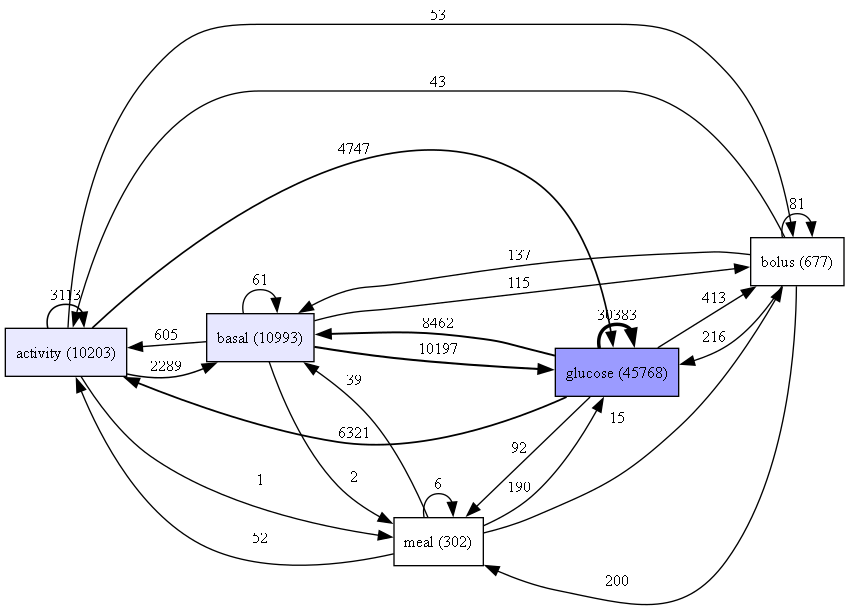

In [ ]:
# Script para gerar um Directly-Follows Graph (usa variáveis já presentes: log, filtered_log, log_df)

# Escolhe o log a usar (prefere filtered_log se não vazio)
source_log = filtered_log if 'filtered_log' in globals() and len(filtered_log) > 0 else log
print("Usando log:", "filtered_log" if source_log is filtered_log else "log")
print("Número de traces no log escolhido:", len(source_log))

# Descobrir DFG (frequência)
dfg = dfg_discovery.apply(source_log, variant=dfg_discovery.Variants.FREQUENCY)

# Sumário rápido dos principais pares directly-follows
top = sorted(dfg.items(), key=lambda kv: kv[1], reverse=True)[:20]
print("Top directly-follows (orig -> dest : count):")
for (a, b), c in top:
    print(f"  {a} -> {b} : {c}")

# Tentar visualizar com pm4py (Graphviz). Guardar imagem e mostrar no notebook.
try:
    gviz = dfg_visualizer.apply(dfg, log=source_log, variant=dfg_visualizer.Variants.FREQUENCY)
    out_path = "dfg_pm4py.png"
    dfg_visualizer.save(gviz, out_path)
    display(Image(out_path))
except Exception as e:
    print("Graphviz/pm4py visualizer falhou:", e)
    print("Usando fallback com networkx/matplotlib...")

    # Fallback: construir grafo networkx e desenhar
    G = nx.DiGraph()
    for (a, b), w in dfg.items():
        if a is None: a = "None"
        if b is None: b = "None"
        G.add_edge(str(a), str(b), weight=w)

    if len(G) == 0:
        print("DFG vazio — nada a desenhar.")
    else:
        plt.figure(figsize=(10, 6))
        pos = nx.spring_layout(G, seed=42)
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        nx.draw_networkx_nodes(G, pos, node_size=1400, node_color="#f0f0f0")
        nx.draw_networkx_labels(G, pos, font_size=10)
        nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=16, width=[max(1, w/3) for w in weights])
        edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
        plt.axis('off')
        plt.title("Directly-Follows Graph (fallback)")
        plt.show()

## 🕸️ Visualização dos modelos descobertos
Visualizamos os modelos de processo obtidos pelos mineradores.


Heuristics Petri Net visualization:


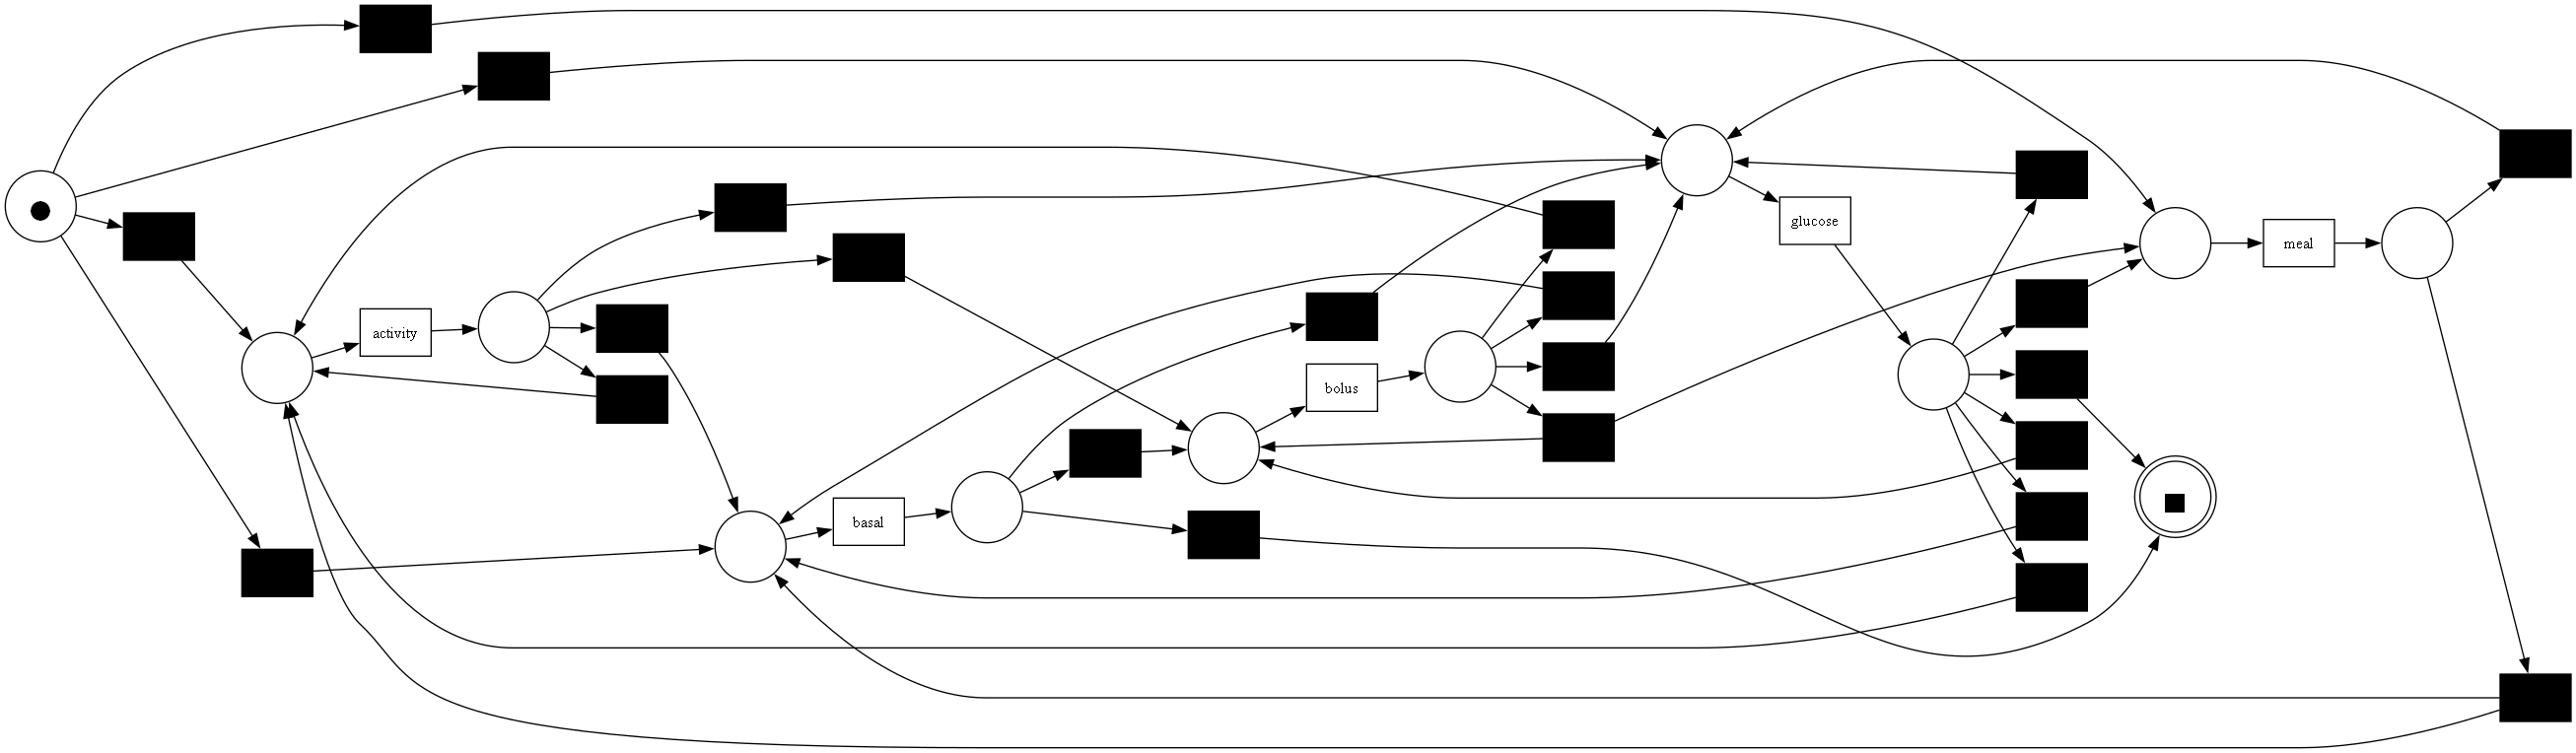

Inductive Petri Net visualization:


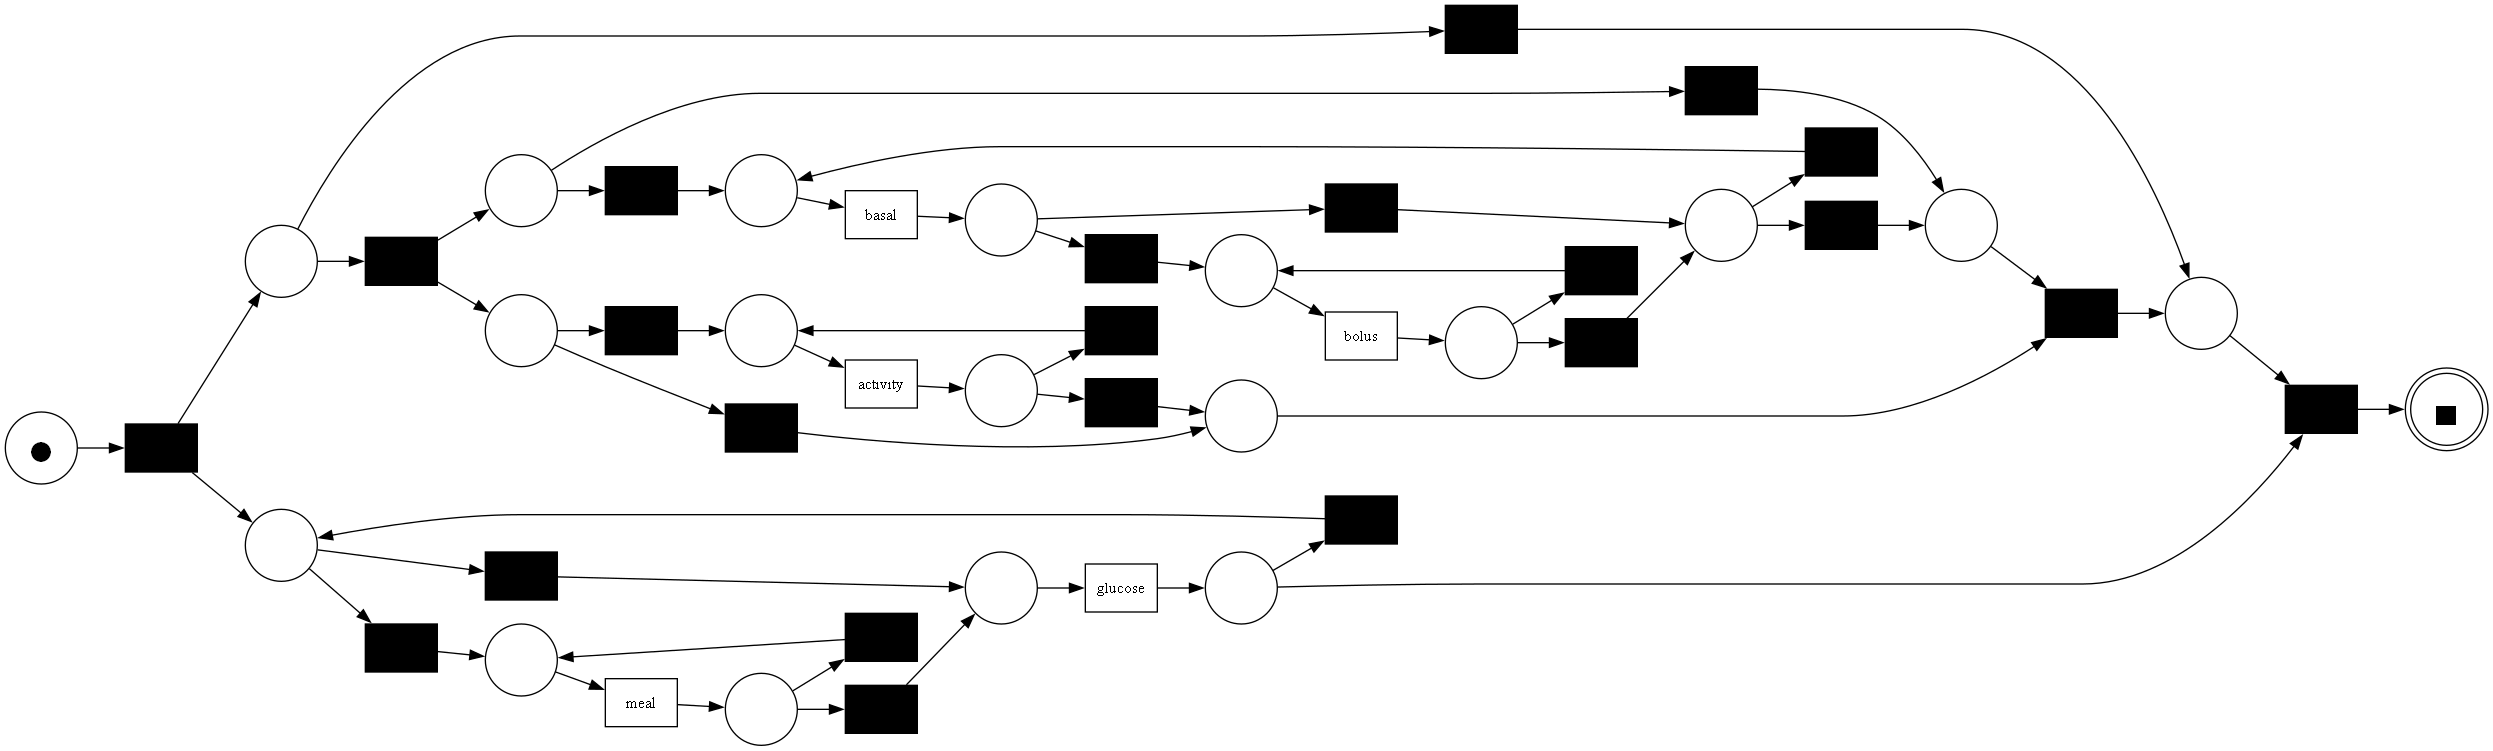

In [11]:
try:
    if hf_net is not None:
        hf_gviz = pn_visualizer.apply(hf_net, hf_im, hf_fm)
        print("Heuristics Petri Net visualization:")
        pn_visualizer.view(hf_gviz)
    else:
        print("hf_net vazio, não visualizo Heuristics (filtered).")

    if if_net is not None:
        if_gviz = pn_visualizer.apply(if_net, if_im, if_fm)
        print("Inductive Petri Net visualization:")
        pn_visualizer.view(if_gviz)
    else:
        print("if_net vazio, não visualizo Inductive (filtered).")
except Exception as e:
    print("Erro ao visualizar (talvez ambiente headless). Exceção:", e)



## 🧮 Avaliação dos modelos
Medimos a qualidade dos modelos segundo métricas de fitness, precisão e generalização.


In [10]:
iii_result = evaluation.apply(log, h_net, h_im, h_fm)
iv_result = evaluation.apply(filtered_log, hf_net, hf_im, hf_fm)
v_result = evaluation.apply(log, i_net, i_im, i_fm)
vi_result = evaluation.apply(filtered_log, if_net, if_im, if_fm)

print("Heuristics Miner (log original):"); pprint(iii_result)
print("\nHeuristics Miner (log filtrado):"); pprint(iv_result)
print("\nInductive Miner (log original):"); pprint(v_result)
print("\nInductive Miner (log filtrado):"); pprint(vi_result)


replaying log with TBR, completed traces ::   0%|          | 0/98 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 🎯 Análise de Conformance com Token Replay
Verificamos quantos traces se encaixam (fit) no modelo descoberto.


In [ ]:
replayed_traces = token_replay.apply(filtered_log, hf_net, hf_im, hf_fm)

not_fit = sum(not t['trace_is_fit'] for t in replayed_traces)
print("Número de traces não conformes:", not_fit)


# ✅ Conclusão
Neste notebook, exploramos:
- Leitura e preparação de logs de eventos
- Definição de *case notion*
- Mineração de processos com PM4Py
- Visualização e avaliação de modelos
- Verificação de conformidade (token replay)

> Próximos passos:
> - Experimentar diferentes *case notions*  
> - Usar logs reais (ERP, CRM, etc.)  
> - Avaliar modelos com métricas avançadas de precisão e generalização
